# Los tres grafos y su recuperación, en detalle: HippoRAG 2 · CatRAG · CatRAG-Reif

Cuaderno didáctico que compara **sobre artefactos reales** las dos cosas que distinguen a
los tres sistemas:

1. **La representación en el grafo** (fase de índice) — cómo queda *el mismo hecho* del
   corpus en cada sistema, con el subgrafo dibujado.
2. **El proceso de recuperación, operación por operación** (fase de consulta) —
   afinidad, enlazado, plan, siembra, paseo, salto y conjunto, cada uno explicado y
   ejecutado.

Se usan **cuatro preguntas conductoras**, una por tipo de 2WikiMultihopQA, elegidas de
modo que HippoRAG 2 falle la cadena y CatRAG-Reif la complete, para que el contraste sea
visible en cada operación.

> Ejecutar con el **kernel del venv** del proyecto (`igraph`, `pandas`, `networkx`,
> `matplotlib`). Coste de API ≈ 0: las llamadas del analista están cacheadas; solo se paga
> el embedding de cada pregunta (~0,0004 \$ en total).

In [1]:
import json, pickle, glob, re, os, sys, textwrap
import numpy as np, pandas as pd
import matplotlib; matplotlib.use('inline') if False else None
import matplotlib.pyplot as plt, networkx as nx
sys.path.insert(0,'../src')
R='../artifacts/wiki2'; H=f'{R}/hipporag_benchmark/gpt-4o-mini_text-embedding-3-small'
corpus  = {c['title']:c['text'] for c in json.load(open('../HippoRAG/reproduce/dataset/2wikimultihopqa_corpus.json'))}
pregs   = {q['_id']:q for q in json.load(open('../HippoRAG/reproduce/dataset/2wikimultihopqa.json'))}
res_h   = {json.loads(l)['_id']:json.loads(l) for l in open(f'{R}/resultados_hipporag2_benchmark.jsonl')}
res_r   = {json.loads(l)['_id']:json.loads(l) for l in open(f'{R}/resultados_plan_deepseek_benchmark.jsonl')}

# --- cuatro preguntas conductoras (una por tipo) ---
def busca(pref): return next(i for i,q in pregs.items() if q['question'].startswith(pref))
CASOS = {
 'compositional'    : busca("Where was the place of death of Maurice, Prince Of Orange's father"),
 'comparison'       : busca("Do Walfredo Reyes Jr. and Zac Dysert have the same nationality"),
 'bridge_comparison': busca("Which film has the director who is older, God"),
 'inference'        : busca("Who is Marianus V Of Arborea's mother"),
}
for t,i in CASOS.items():
    q=pregs[i]; print(f"[{t:17}] {q['question']}")
    print(f"{'':21}oro: {[x for x,_ in q['supporting_facts']]}")

[compositional    ] Where was the place of death of Maurice, Prince Of Orange's father?
                     oro: ['Maurice, Prince of Orange', 'William the Silent']
[comparison       ] Do Walfredo Reyes Jr. and Zac Dysert have the same nationality?
                     oro: ['Walfredo Reyes Jr.', 'Zac Dysert']
[bridge_comparison] Which film has the director who is older, God'S Gift To Women or Aldri Annet Enn Bråk?
                     oro: ["God's Gift to Women", 'Aldri annet enn bråk', 'Michael Curtiz', 'Edith Carlmar']
[inference        ] Who is Marianus V Of Arborea's mother?
                     oro: ['Marianus V of Arborea', 'Brancaleone Doria']


## Parte 1 · La representación en el grafo (índice)

Los tres sistemas parten del **mismo corpus**; difieren en cómo lo estructuran.

### 1.1 · HippoRAG 2 — hechos como *aristas*, menciones sin resolver

HippoRAG 2 extrae tripletes `(sujeto, relación, objeto)` y los materializa como
**aristas entre nodos-frase** (las menciones en minúsculas), más aristas de *sinonimia*
(coseno de nombres) y de *contexto* (frase→pasaje). Cargamos su grafo oficial, tal como lo
construyó su propio código en nuestra reproducción.

In [2]:
import igraph
G=pickle.load(open(f'{H}/graph.pickle','rb'))
ent=pd.concat([pd.read_parquet(p) for p in glob.glob(f'{H}/entity_embeddings/*.parquet')])
chk=pd.concat([pd.read_parquet(p) for p in glob.glob(f'{H}/chunk_embeddings/*.parquet')])
h2f=dict(zip(ent['hash_id'],ent['content']))            # hash -> frase-mencion
h2c=dict(zip(chk['hash_id'],chk['content']))            # hash -> texto del pasaje
titulo=lambda h:h2c.get(h,'').split(chr(10),1)[0][:55]  # 1a linea del pasaje = titulo
er=[a for a in G.es.attributes() if a!='weight']        # atributo textual de la relacion
print(f'grafo HippoRAG 2:  {G.vcount():,} nodos  |  {G.ecount():,} aristas')
from collections import Counter
tipos=Counter('pasaje' if n.startswith('chunk') else 'frase-mencion' for n in G.vs['name'])
print('tipos de nodo :', dict(tipos))
print('atributo de arista (relacion):', er)

grafo HippoRAG 2:  56,127 nodos  |  305,826 aristas
tipos de nodo : {'frase-mencion': 50008, 'pasaje': 6119}
atributo de arista (relacion): []


In [3]:
# El hecho puente del caso bridge, TAL COMO VIVE en su grafo: una arista anonima
def aristas_incidentes(patron, maxn=8):
    out=[]
    for e in G.es:
        s=h2f.get(G.vs[e.source]['name']); t=h2f.get(G.vs[e.target]['name'])
        if s is None or t is None: continue                 # es arista de contexto a pasaje
        rel=e[er[0]] if er else ''
        if patron in (s+' '+str(rel)+' '+t).lower(): out.append((s,rel,t))
    return out[:maxn]
print("aristas-triplete que tocan «god's gift to women»:")
for s,r,t in aristas_incidentes("god's gift to women"): print(f'    ({s})  --[{r}]-->  ({t})')

aristas-triplete que tocan «god's gift to women»:


In [4]:
# Fragmentacion de identidad: la MISMA persona aparece como varios nodos distintos
for quien in ('curtiz','william the silent','maurice of orange'):
    vs=sorted({f for f in h2f.values() if quien.split()[0] in f.lower() and
               any(w in f.lower() for w in quien.split())})
    print(f'nodos-frase para «{quien}»:', vs[:6])

nodos-frase para «curtiz»: ['michael curtiz']
nodos-frase para «william the silent»: ['1939 william saroyan play', '2nd baronet williams of bodelwyddan', 'andy williams', 'angela williams', 'ann williams', 'anthony tillmon williams']
nodos-frase para «maurice of orange»: ['c  maurice patterson', 'christopher maurice brown', 'count william maurice of solms braunfels', 'david maurice graham', 'george fitzmaurice', 'half brother of maurice of nassau']


**Puntos clave de la representación de HippoRAG 2:** el hecho es una **arista** (la
relación es un atributo textual, sin frase propia ni procedencia direccionable); las
menciones **no están resueltas** (varias formas de una misma persona son nodos distintos);
la única costura entre variantes son las **aristas de sinonimia por umbral**, que fallan
cuando el coseno de dos nombres queda por debajo del umbral.

### 1.2 · CatRAG — el mismo grafo

CatRAG (código no liberado; mecanismo según su artículo, cifras publicadas con *nuestro
mismo backbone*) **no cambia nada en indexación**: reutiliza el grafo de tripletes de
HippoRAG 2. Sus tres mecanismos (anclas simbólicas débiles, re-ponderación de aristas por
LLM, refuerzo de pasajes con hechos verificados) actúan **solo en consulta**. Por tanto su
representación en el grafo es, píxel a píxel, la de la sección 1.1.

### 1.3 · CatRAG-Reif — hechos como *nodos* sobre entidades canónicas

Dos decisiones de índice: (i) cada hecho se **reifica** en un nodo con frase autocontenida
`τ_a`, roles n-arios y procedencia; (ii) las menciones se **resuelven** antes de construir
el grafo, en una *memoria canónica* (alias + descripción + *pasaje propio*), de modo que el
grafo **no lleva aristas de sinonimia**.

In [5]:
from asistente_vih.retrieval.wiki2_plan import Wiki2PlanRAG
r4=Wiki2PlanRAG(split='benchmark', modelo='deepseek-chat')     # ~1-2 min: grafo 84k + vectores
from collections import Counter
print('grafo CatRAG-Reif: {:,} nodos  |  {:,} aristas'.format(r4.g.number_of_nodes(), r4.g.number_of_edges()))
print('tipos de nodo :', dict(Counter(d.get('tipo') for _,d in r4.g.nodes(data=True))))
print('tipos de arista:', dict(Counter(d.get('tipo_relacion') for _,_,d in r4.g.edges(data=True))))

grafo CatRAG-Reif: 81,058 nodos  |  165,240 aristas
tipos de nodo : {'Chunk': 6119, 'Entidad': 26940, 'Asercion': 47999}
tipos de arista: {'MENCIONADO_EN': 36811, 'EN_CHUNK': 47999, 'HAS_INTERVENTION': 47466, 'HAS_OUTCOME': 32964}


In [6]:
# El MISMO hecho puente, ahora como NODO de primera clase
aid=next(a for a in r4.aser_ids if 'curtiz' in r4.g.nodes[a].get('descripcion','').lower()
         and "god's gift" in r4.g.nodes[a].get('descripcion','').lower())
n=r4.g.nodes[aid]
print('id nodo-aserción :', aid)
print('frase τ_a        :', n['descripcion'])
print('relación         :', n.get('relacion_base'))
print('roles / aristas del hecho:')
for _,v,d in r4.g.out_edges(aid, data=True): print(f'    --{d["tipo_relacion"]:>16}-->  {v}')

id nodo-aserción : God's Gift to Women::a1
frase τ_a        : God's Gift to Women was directed by Michael Curtiz.
relación         : DIRECTED
roles / aristas del hecho:
    --        EN_CHUNK-->  chunk:God's Gift to Women
    --HAS_INTERVENTION-->  can:god's gift to women
    --     HAS_OUTCOME-->  can:michael curtiz


In [7]:
# Identidad resuelta: UNA entrada canonica por persona, con alias y pasaje propio
for eid in ('can:michael curtiz','can:edith carlmar','can:william the silent'):
    e=r4.entradas.get(eid)
    if e: print(eid,'->',{k:e[k] for k in ('nombre','alias','pasaje_propio','n_menciones')})

can:michael curtiz -> {'nombre': 'Michael Curtiz', 'alias': ['Michael Curtiz'], 'pasaje_propio': 'Michael Curtiz', 'n_menciones': 9}
can:edith carlmar -> {'nombre': 'Edith Carlmar', 'alias': ['Carlmar Film A/S', 'Edith Carlmar'], 'pasaje_propio': 'Edith Carlmar', 'n_menciones': 5}


### 1.4 · El mismo hecho, dibujado en ambas representaciones

A la izquierda, la representación de HippoRAG 2/CatRAG (hecho = arista, con las variantes de
nombre como nodos sueltos que exigen sinonimia). A la derecha, la de CatRAG-Reif (hecho =
nodo con frase y procedencia, sobre entidades canónicas).

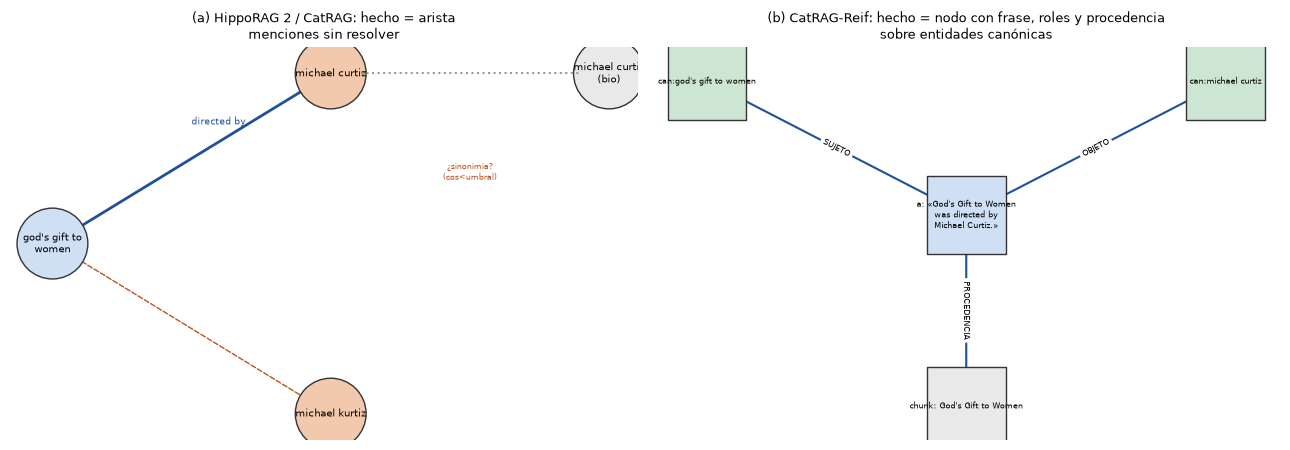

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4.6))
# --- izquierda: triplete plano + fragmentacion
gL=nx.DiGraph()
gL.add_edge("god's gift to women","michael curtiz",rel='directed by')
gL.add_edge("god's gift to women","michael kurtiz",rel='')      # variante NER
gL.add_node("michael curtiz (bio)")
posL={"god's gift to women":(0,1),"michael curtiz":(1.4,1.4),"michael kurtiz":(1.4,0.6),"michael curtiz (bio)":(2.8,1.4)}
nx.draw_networkx_nodes(gL,posL,ax=ax1,node_color=['#cfe0f5','#f2c9ad','#f2c9ad','#e9e9e9'],node_size=2600,edgecolors='#333')
nx.draw_networkx_labels(gL,posL,ax=ax1,font_size=7,labels={k:textwrap.fill(k,14) for k in gL})
nx.draw_networkx_edges(gL,posL,ax=ax1,edgelist=[("god's gift to women","michael curtiz")],edge_color='#1f509a',width=2)
nx.draw_networkx_edges(gL,posL,ax=ax1,edgelist=[("god's gift to women","michael kurtiz")],edge_color='#ba5420',style='dashed')
ax1.plot([1.55,2.65],[1.4,1.4],':',color='#999'); ax1.annotate('¿sinonimia?\n(cos<umbral)',(2.1,1.15),fontsize=6,color='#ba5420',ha='center')
ax1.annotate('directed by',(0.7,1.28),fontsize=6.5,color='#1f509a')
ax1.set_title('(a) HippoRAG 2 / CatRAG: hecho = arista\nmenciones sin resolver',fontsize=9); ax1.axis('off')
# --- derecha: asercion-nodo canonica
gR=nx.DiGraph()
gR.add_edge('a: «God\'s Gift to Women\nwas directed by\nMichael Curtiz.»','can:god\'s gift to women',rel='SUJETO')
gR.add_edge('a: «God\'s Gift to Women\nwas directed by\nMichael Curtiz.»','can:michael curtiz',rel='OBJETO')
gR.add_edge('a: «God\'s Gift to Women\nwas directed by\nMichael Curtiz.»','chunk: God\'s Gift to Women',rel='PROCEDENCIA')
posR={'a: «God\'s Gift to Women\nwas directed by\nMichael Curtiz.»':(1.4,1),'can:god\'s gift to women':(0,1.7),'can:michael curtiz':(2.8,1.7),'chunk: God\'s Gift to Women':(1.4,0)}
nx.draw_networkx_nodes(gR,posR,ax=ax2,node_size=3200,node_shape='s',
    node_color=['#cfe0f5','#cde6d3','#cde6d3','#e9e9e9'],edgecolors='#333')
nx.draw_networkx_labels(gR,posR,ax=ax2,font_size=6)
nx.draw_networkx_edges(gR,posR,ax=ax2,edge_color='#1f509a',width=1.5)
nx.draw_networkx_edge_labels(gR,posR,ax=ax2,edge_labels=nx.get_edge_attributes(gR,'rel'),font_size=6)
ax2.set_title('(b) CatRAG-Reif: hecho = nodo con frase, roles y procedencia\nsobre entidades canónicas',fontsize=9); ax2.axis('off')
plt.tight_layout(); plt.show()

In [9]:
# Estadisticas comparadas de las tres representaciones (sobre el corpus de 6.119 pasajes)
import pandas as pd
tab=pd.DataFrame([
 ['unidad del hecho','arista (triplete)','arista (triplete)','nodo-aserción con frase τ'],
 ['identidad de entidad','sin resolver','sin resolver','canónica (memoria de entidades)'],
 ['aristas de sinonimia','~172.000 (umbral)','~172.000','0 (fusión en el índice)'],
 ['procedencia del hecho','arista de contexto','idem','arista EN_CHUNK por hecho'],
 ['nodos del grafo',f'{G.vcount():,}','(el mismo)',f'{r4.g.number_of_nodes():,}'],
], columns=['propiedad','HippoRAG 2','CatRAG','CatRAG-Reif'])
tab

,propiedad,HippoRAG 2,CatRAG,CatRAG-Reif
0,unidad del hecho,arista (triplete),arista (triplete),nodo-aserción con frase τ
1,identidad de entidad,sin resolver,sin resolver,canónica (memoria de entidades)
2,aristas de sinonimia,~172.000 (umbral),~172.000,0 (fusión en el índice)
3,procedencia del hecho,arista de contexto,idem,arista EN_CHUNK por hecho
4,nodos del grafo,"56,127",(el mismo),"81,058"


## Parte 2 · El proceso de recuperación, operación por operación

Recorremos la consulta de **CatRAG-Reif** sobre el caso *bridge-comparison* (el más
exigente: 4 pasajes oro), explicando **qué hace y por qué** cada operación, y después la
aplicamos a los cuatro casos. Al final re-ejecutamos la mecánica de **HippoRAG 2** sobre
las mismas preguntas para ver dónde descarrila.

In [10]:
QID=CASOS['bridge_comparison']; q=pregs[QID]; oro={t for t,_ in q['supporting_facts']}
print('CASO:', q['question']); print('ORO :', sorted(oro))

CASO: Which film has the director who is older, God'S Gift To Women or Aldri Annet Enn Bråk?
ORO : ['Aldri annet enn bråk', 'Edith Carlmar', "God's Gift to Women", 'Michael Curtiz']


### Operación 1 · Afinidad global pregunta↔hecho

Se codifica la pregunta con el mismo embedder del índice y se calcula, de un **solo
producto matricial**, el coseno `σ_a = ⟨e(q), e(τ_a)⟩` contra las 47.999 frases-aserción.
Es una preselección barata; nótese que los mejores por coseno son hechos *superficialmente*
parecidos a la pregunta, no necesariamente los útiles.

In [11]:
qv=r4._qvecs(q['question'],'lite')[0]; sims=r4.aser_emb@qv
print('top-6 hechos por coseno (semejanza, no utilidad):')
for j in np.argsort(-sims)[:6]:
    print(f'   σ={sims[j]:.3f}  {r4.g.nodes[r4.aser_ids[int(j)]]["descripcion"][:92]}')

top-6 hechos por coseno (semejanza, no utilidad):
   σ=0.554  God's Gift to Women was directed by Michael Curtiz.
   σ=0.517  God's Gift to Women was originally completed as a musical film.
   σ=0.516  God's Gift to Women was released in 1931.
   σ=0.507  God's Gift to Women stars Joan Blondell.
   σ=0.480  Edith Carlmar is known for the film 'Aldri annet enn bråk'.
   σ=0.477  God's Gift to Women is based on the play The Devil Was Sick.


### Operación 2 · Enlazado de menciones contra la memoria canónica

Las menciones de la pregunta se resuelven a **entradas canónicas** (alias exacto; si falla,
coseno de ficha ≥0,80). Cada entrada enlazada aporta (a) su *pasaje propio* para la siembra
y (b) su *frontera* de hechos como candidatos del filtro — de modo que el hecho puente
entra en la lista **por estructura del grafo** aunque su coseno no lo suba al top-40.

In [12]:
L=r4._enlazar_menciones(q['question'])
for e in L:
    en=r4.entradas[e]; print(f'   {e}  ->  pasaje propio: {en["pasaje_propio"]}')
print('\nfrontera (hechos colgados de las entidades enlazadas), muestra:')
fr=r4._frontera(L, sims)
for j in fr[:6]: print('   *', r4.g.nodes[r4.aser_ids[j]]['descripcion'][:92])

   can:god's gift to women  ->  pasaje propio: God's Gift to Women
   can:aldri annet enn bråk  ->  pasaje propio: Aldri annet enn bråk

frontera (hechos colgados de las entidades enlazadas), muestra:
   * God's Gift to Women was directed by Michael Curtiz.
   * God's Gift to Women was originally completed as a musical film.
   * God's Gift to Women was released in 1931.
   * God's Gift to Women stars Joan Blondell.
   * God's Gift to Women is based on the play The Devil Was Sick.
   * God's Gift to Women stars Laura LaPlante.


### Operación 3 · El analista: *planificar* la cadena y luego seleccionar

Una llamada LLM (cacheada) recibe la pregunta y los candidatos (top-40 por coseno ∪
frontera) y devuelve: el **plan** de la cadena como huecos tipados; la **selección** de
hechos que rellenan huecos (tope = nº de huecos); y los **huecos sin cubrir**. La regla dura
—prohibido rellenar un hueco con conocimiento propio del modelo— fuerza a declarar como
hueco lo que no esté en un hecho candidato.

In [13]:
apr,huecos,L2,plan=r4._analista(q['question'],sims,L)
print('PLAN (cadena de evidencia como huecos):')
for p in plan: print('   -',p)
print('\nHECHOS SELECCIONADOS (S(q)):')
for j in apr: print('   *',r4.g.nodes[r4.aser_ids[j]]['descripcion'][:92])
print('\nHUECOS SIN CUBRIR (alimentan la Operación 6):',[h.get('query',h) if isinstance(h,dict) else h for h in huecos])

PLAN (cadena de evidencia como huecos):
   - director of God's Gift to Women -> Michael Curtiz
   - date of birth of Michael Curtiz
   - director of Aldri annet enn bråk -> Edith Carlmar
   - date of birth of Edith Carlmar

HECHOS SELECCIONADOS (S(q)):
   * God's Gift to Women was directed by Michael Curtiz.
   * Aldri annet enn bråk was edited by Edith Carlmar.

HUECOS SIN CUBRIR (alimentan la Operación 6): ['date of birth of Michael Curtiz', 'date of birth of Edith Carlmar']


### Operación 4 · Siembra: el vector de personalización `v`

La masa de reinicio del paseo se concentra donde importa, con cuatro fuentes: (a)
**compuerta dura** — solo siembran las entidades de los hechos aprobados (peso 1); (b)
**presa densa** sobre todos los pasajes (×0,05); (c) **anclas débiles** (ε); y (d)
**pasaje propio** — cada entidad sembrada vierte 0,5·su masa en *su* artículo (`v(π(ε))`).
El término (d) es el que convierte a un director *descubierto* (no nombrado en la pregunta)
en un pasaje directamente sembrado.

In [14]:
st=sims.copy(); st[apr]=1.0; r4._enlaces_actuales=L2
v=r4._semillas(q['question'],[qv],st,apr)
print('componentes de v con más masa (entidades y pasajes):')
for n,w in sorted(v.items(),key=lambda x:-x[1])[:10]:
    tipo='entidad' if n.startswith(('can:','ent:')) else 'pasaje'
    print(f'   {w:6.3f}  [{tipo}]  {n}')

componentes de v con más masa (entidades y pasajes):
    1.050  [entidad]  can:god's gift to women
    1.050  [entidad]  can:michael curtiz
    1.000  [entidad]  can:aldri annet enn bråk
    1.000  [entidad]  can:edith carlmar
    0.575  [pasaje]  chunk:God's Gift to Women
    0.555  [pasaje]  chunk:Michael Curtiz
    0.546  [pasaje]  chunk:Edith Carlmar
    0.545  [pasaje]  chunk:Aldri annet enn bråk
    0.046  [pasaje]  chunk:Winter Light
    0.046  [pasaje]  chunk:Through a Glass Darkly (film)


### Operación 5 · Paseo aleatorio con transiciones moduladas (PPR)

La adyacencia se **modula por consulta**: las columnas que entran a cada nodo-aserción se
escalan por `μ_a = ¼ + ¾·σ̃_a` (los hechos *aprobados* transitan a peso completo, μ=1;
ninguno baja de ¼). Se renormaliza por filas y se itera el PageRank personalizado (λ=0,5).
La masa fluye **a través** de los hechos aprobados hacia sus entidades y pasajes.

In [15]:
p=r4._ppr(v,st)
top=[r4.nodos[i][6:] for i in np.argsort(-p) if r4.nodos[i].startswith('chunk:')][:10]
print('top-10 pasajes tras el paseo (antes del salto/conjunto):')
for k,t in enumerate(top): print(f'   {k+1:2d}. {t}'+('  <== ORO' if t in oro else ''))

top-10 pasajes tras el paseo (antes del salto/conjunto):
    1. God's Gift to Women  <== ORO
    2. Edith Carlmar  <== ORO
    3. Aldri annet enn bråk  <== ORO
    4. Michael Curtiz  <== ORO
    5. Altid ballade
    6. Bedre enn sitt rykte
    7. Mrs. Dane's Confession
    8. Prisoner of the Night (film)
    9. The Lady Takes a Sailor
   10. The Vagabond King (1956 film)


### Operación 6 · Salto dirigido (si el plan dejó huecos)

Por cada hueco sin cubrir (aquí: *fecha de nacimiento de cada director*), se buscan hechos
candidatos **estructurales** —las aserciones del *pasaje propio* de la entidad del hueco—
más los afines por coseno; un mini-filtro LLM aprueba los que rellenan el hueco, se
re-siembra y se re-itera el paseo una vez. Es lo que rescata puentes cuyo artículo usa otro
nombre/idioma, imposible para similitud o sinonimia.

In [16]:
# el salto va dentro de buscar(); mostramos su efecto comparando antes/después
final=r4.buscar(q['question'],5)
print('CONJUNTO FINAL (Operación 7 incluida):')
for k,t in enumerate(final): print(f'   {k+1}. {t}'+('  <== ORO' if t in oro else ''))

CONJUNTO FINAL (Operación 7 incluida):
   1. God's Gift to Women  <== ORO
   2. Michael Curtiz  <== ORO
   3. Aldri annet enn bråk  <== ORO
   4. Edith Carlmar  <== ORO
   5. Altid ballade


### Operación 7 · Empaquetado del conjunto final

`FC@k` es una propiedad **del conjunto**, no de cada pasaje: un ranking punto a punto no
puede optimizarla. Una última llamada LLM recibe el plan y el top-12 del paseo y elige los 5
que **juntos** cubren todos los huecos (con una guarda: el top-2 del paseo se conserva). Su
efecto principal es de *orden temprano* (+6 puntos de FC@2).

In [17]:
print('métrica final del caso:  R@5 = {:.2f}   FC@5 = {}'.format(
      res_r[QID]['recall@5'], int(set(oro)<=set(final))))

métrica final del caso:  R@5 = 1.00   FC@5 = 1


### 2.8 · Las mismas operaciones sobre los cuatro tipos de pregunta

Resumimos, por caso, la salida de las operaciones decisivas: enlaces, plan, hechos
aprobados y conjunto final.

In [18]:
for tipo,i in CASOS.items():
    q=pregs[i]; oroi={t for t,_ in q['supporting_facts']}
    qvi=r4._qvecs(q['question'],'lite')[0]; si=r4.aser_emb@qvi
    Li=r4._enlazar_menciones(q['question'])
    ap,hu,Li2,pl=r4._analista(q['question'],si,Li)
    fin=r4.buscar(q['question'],5)
    print('═'*94); print(f'[{tipo}]  {q["question"]}')
    print('  enlaces :',[r4.entradas[e]['nombre'] for e in Li])
    print('  plan    :', ' | '.join(pl))
    print('  aprob.  :',[r4.g.nodes[r4.aser_ids[j]]['relacion_base'] for j in ap])
    print('  top-5   :',[('*'+t if t in oroi else t) for t in fin])
    print(f'  R@5={res_r[i]["recall@5"]:.2f}  FC@5={int(set(oroi)<=set(fin))}   (* = oro)')

══════════════════════════════════════════════════════════════════════════════════════════════
[compositional]  Where was the place of death of Maurice, Prince Of Orange's father?
  enlaces : ['Maurice, Prince of Orange']
  plan    : father of Maurice, Prince Of Orange -> William I, Prince of Orange | place of death of William I, Prince of Orange
  aprob.  : ['FATHER_OF', 'ASSASSINATED_BY']
  top-5   : ['*William the Silent', '*Maurice, Prince of Orange', 'William I, Count of Nassau-Dillenburg', 'Elisabeth of Nassau-Dillenburg, Countess of Wied', 'Margaretha van Mechelen']
  R@5=1.00  FC@5=1   (* = oro)


══════════════════════════════════════════════════════════════════════════════════════════════
[comparison]  Do Walfredo Reyes Jr. and Zac Dysert have the same nationality?
  enlaces : ['Walfredo Reyes Jr.', 'Zac Dysert']
  plan    : nationality of Walfredo Reyes Jr. -> [X] | nationality of Zac Dysert -> [X]
  aprob.  : []
  top-5   : ['*Walfredo Reyes Jr.', '*Zac Dysert', 'Walfredo de los Reyes', 'Elan Atias', 'Sergio Reyes Jr.']
  R@5=1.00  FC@5=1   (* = oro)


══════════════════════════════════════════════════════════════════════════════════════════════
[bridge_comparison]  Which film has the director who is older, God'S Gift To Women or Aldri Annet Enn Bråk?
  enlaces : ["God's Gift to Women", 'Aldri annet enn bråk']
  plan    : director of God's Gift to Women -> Michael Curtiz | date of birth of Michael Curtiz | director of Aldri annet enn bråk -> Edith Carlmar | date of birth of Edith Carlmar
  aprob.  : ['DIRECTED', 'EDITED']
  top-5   : ["*God's Gift to Women", '*Michael Curtiz', '*Aldri annet enn bråk', '*Edith Carlmar', 'Altid ballade']
  R@5=1.00  FC@5=1   (* = oro)


══════════════════════════════════════════════════════════════════════════════════════════════
[inference]  Who is Marianus V Of Arborea's mother?
  enlaces : ['Marianus V of Arborea']
  plan    : mother of Marianus V of Arborea -> [X]
  aprob.  : ['MOTHER_OF', 'TUTELAGE_OF']
  top-5   : ['*Marianus V of Arborea', '*Brancaleone Doria', 'William II of Narbonne', 'Hugh II of Arborea', 'Marianus I of Arborea']
  R@5=1.00  FC@5=1   (* = oro)


## Parte 3 · La misma consulta en HippoRAG 2, y por qué descarrila

Re-ejecutamos su mecánica —siembra desde las entidades *nombradas* en la pregunta + PPR
**estático** sobre su propio grafo— y la contrastamos con su top-5 medido. En las
comparaciones-puente la entidad puente (el director) **no está nombrada**, así que su
siembra cubre una sola rama y la matriz estática no puede repartir lo que no se sembró.

In [19]:
frase2hash={v:k for k,v in h2f.items()}
idx={n:i for i,n in enumerate(G.vs['name'])}
def hippo_estatico(qid, sem_frases):
    reset=[0.0]*G.vcount(); usados=[]
    for f in sem_frases:
        h=frase2hash.get(f)
        if h in idx: reset[idx[h]]=1.0; usados.append(f)
    if sum(reset)==0: return [],usados
    w=G.es['weight'] if 'weight' in G.es.attributes() else None
    pr=G.personalized_pagerank(damping=0.5,reset=reset,weights=w,implementation='prpack')
    pas=sorted(((titulo(G.vs[i]['name']),pr[i]) for i in range(G.vcount())
                if G.vs[i]['name'].startswith('chunk')),key=lambda x:-x[1])
    return pas[:6],usados

# bridge: sembramos solo la rama que su NER nombraria (los dos films)
pas,us=hippo_estatico(CASOS['bridge_comparison'],
        ["god's gift to women","aldri annet enn braak","aldri annet enn bråk"])
oro={t for t,_ in pregs[CASOS['bridge_comparison']]['supporting_facts']}
print('semillas usadas:',us)
print('paseo estático de HippoRAG (top-6):')
for t,pp in pas: print(f'   {pp:.5f}  {t}'+('  <== ORO' if any(o.lower() in t.lower() for o in oro) else '  (deriva)'))

semillas usadas: []
paseo estático de HippoRAG (top-6):


In [20]:
# lo que su sistema COMPLETO (filtro incluido) devolvio, medido, en los 4 casos
print('HippoRAG 2 — top-5 MEDIDO por caso (vs. CatRAG-Reif):')
for tipo,i in CASOS.items():
    oroi={t for t,_ in pregs[i]['supporting_facts']}
    th=res_h[i]['top'][:5]; tr=res_r[i]['top'][:5]
    print('─'*94); print(f'[{tipo}]')
    print('  HippoRAG 2 :',[('*'+t if t in oroi else t) for t in th],f'FC@5={int(res_h[i]["full_chain@5"])}')
    print('  CatRAG-Reif:',[('*'+t if t in oroi else t) for t in tr],f'FC@5={int(res_r[i]["full_chain@5"])}')

HippoRAG 2 — top-5 MEDIDO por caso (vs. CatRAG-Reif):
──────────────────────────────────────────────────────────────────────────────────────────────
[compositional]
  HippoRAG 2 : ['*Maurice, Prince of Orange', 'Margaretha van Mechelen', 'Louis of Nassau, Lord of De Lek and Beverweerd', 'William of Nassau (1601–1627)', 'William of Nassau (1620–1679)'] FC@5=0
  CatRAG-Reif: ['*William the Silent', '*Maurice, Prince of Orange', 'William I, Count of Nassau-Dillenburg', 'Elisabeth of Nassau-Dillenburg, Countess of Wied', 'Margaretha van Mechelen'] FC@5=1
──────────────────────────────────────────────────────────────────────────────────────────────
[comparison]
  HippoRAG 2 : ['*Walfredo Reyes Jr.', 'Walfredo de los Reyes', 'Sergio Reyes Jr.', 'Ernie Reyes Sr.', 'Carlos Reyes (baseball)'] FC@5=0
  CatRAG-Reif: ['*Zac Dysert', '*Walfredo Reyes Jr.', 'Walfredo de los Reyes', 'Elan Atias', 'Sergio Reyes Jr.'] FC@5=1
──────────────────────────────────────────────────────────────────────────────

## Parte 4 · Síntesis

| | HippoRAG 2 | CatRAG | CatRAG-Reif |
|---|---|---|---|
| **índice** | tripletes-arista + sinonimia; menciones sin resolver | *el mismo* | aserciones-nodo sobre entidades canónicas; sin sinonimia |
| **afinidad** | coseno pregunta↔triplete | idem | coseno pregunta↔frase τ (más informativa) |
| **anclaje** | NER de la pregunta | NER + anclas ε | enlazador contra el diccionario + frontera |
| **selección** | filtro LLM ≤4 (una rama) | idem | analista: **plan** + selección con tope por huecos |
| **siembra** | frases de los triples filtrados | *la misma* | compuerta dura + **pasaje propio** de cada entidad |
| **paseo** | PPR **estático** | re-pondera aristas cerca de semillas | PPR **modulado** por hecho + salto por huecos |
| **decisión final** | top-k del ranking | top-k | **conjunto** que cubre el plan |
| **2Wiki FC@5** | 65,8 | 67,6 (publicado) | **97,7** |

**Lectura.** CatRAG cambia *una* etapa (re-ponderar el paseo) y hereda índice y siembra: por
eso su mejora es marginal —*re-ponderar aristas no alcanza a una semilla que no existe*—. El
salto de calidad de CatRAG-Reif viene de cambiar el **índice** (representar mejor + resolver
la identidad) y de asignar los recursos de consulta **por hueco del plan**, no por consulta.
Detalle: `artifacts/wiki2/INFORME.md`, `docs/presentacion_sistema.pdf`,
`docs/paper_draft_en.pdf`.